# **LLM Call In LangGraph**

In [1]:
from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage;
from langchain_groq import ChatGroq;
from dotenv import load_dotenv;

load_dotenv();

llm = ChatGroq(model="openai/gpt-oss-120b");

messages = [
    SystemMessage(content="You are a helpful assistant. Answer in one sentence."),
    HumanMessage(content="What is LangGraph?")
];

response = llm.invoke(messages);

print(f"Response: {response.content}");

Response: LangGraph is an open‑source Python library that lets developers create, visualize, and manage complex, state‑driven workflow graphs by chaining together language‑model components and other functions.


In [2]:
from langgraph.graph import StateGraph, START, END;
from typing import TypedDict, Annotated;
import operator;

class State(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add]; # Base Message Present State All Messages

def chatbot_node(state: State) -> dict:

    response = llm.invoke(state["messages"]);

    return {"messages": [response]};

builder = StateGraph(State);

builder.add_node("chatbot", chatbot_node);

builder.add_edge(START, "chatbot");

builder.add_edge("chatbot", END);

graph = builder.compile();

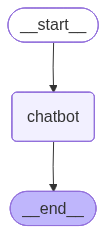

In [3]:
from IPython.display import Image, display;

display(Image(graph.get_graph().draw_mermaid_png()));

In [4]:
result = graph.invoke(
    {
        "messages": [
            SystemMessage(content="You are a helpful assistant. Answer in one sentence."),
            HumanMessage(content="What is LangGraph ?")
        ]
    }
);

result

{'messages': [SystemMessage(content='You are a helpful assistant. Answer in one sentence.', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='What is LangGraph ?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='LangGraph is an open‑source Python framework that lets developers build, visualize, and run complex, state‑ful LLM workflows as directed graphs of modular nodes and edges.', additional_kwargs={'reasoning_content': 'User asks: "What is LangGraph?" They want answer in one sentence. Provide concise definition.'}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 90, 'total_tokens': 155, 'completion_time': 0.13360496, 'completion_tokens_details': {'reasoning_tokens': 21}, 'prompt_time': 0.003550646, 'prompt_tokens_details': None, 'queue_time': 0.24269653, 'total_time': 0.137155606}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_19b184c447', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprob

In [5]:
for msg in result["messages"]:

    print(f"[{msg.type}]  {msg.content}");

[system]  You are a helpful assistant. Answer in one sentence.
[human]  What is LangGraph ?
[ai]  LangGraph is an open‑source Python framework that lets developers build, visualize, and run complex, state‑ful LLM workflows as directed graphs of modular nodes and edges.


# **LLM Node + LLM-Driven Conditional Routing**

In [6]:
from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage;
from typing import TypedDict, Annotated, Literal;
from langchain_groq import ChatGroq;
from dotenv import load_dotenv;
import operator;

load_dotenv();

llm = ChatGroq(model="openai/gpt-oss-120b");

class State(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add];
    category: str;
    response: str;

def classify_node(state: State) -> dict:

    """Ask the LLM to classify the users message"""

    user_msg = state["messages"][-1].content;

    resp = llm.invoke(
        [
            SystemMessage("Classify the user message into exactly one word: question, task or chitchat."),
            HumanMessage(user_msg)
        ]
    );

    category = resp.content.strip().lower();

    print(f"[classify] → {category}");

    return {"category": category};

In [ ]:
def answer_node(state: State) -> dict:

    """Handle factual questions"""

    res = llm.invoke([SystemMessage("You are a knowledgeable assistant.")] + state["messages"]);

    return {"response": res.content};


def task_node(state: State) -> dict:

    """Handle action/task requests"""

    res = llm.invoke([SystemMessage("You are a task-oriented assistant. Be direct and structured.")] + state["messages"]);

    return {"response": res.content};


def chitchat_node(state: State) -> dict:

    """Handle casual conversation"""

    res = llm.invoke([SystemMessage("You are a friendly, casual, fun assistant. Keep it short!")] + state["messages"]);

    return {"response": res.content};

def route_by_category(state: State) -> Literal["answer", "task", "chitchat"]: # Conditional Node

    cat = state["category"];

    if "question" in cat:

        return "answer";

    if "task" in cat:

        return "task";

    return "chitchat";

In [8]:
from langgraph.graph import StateGraph, START, END;

builder = StateGraph(State);

builder.add_node("classify", classify_node);

builder.add_node("answer", answer_node);

builder.add_node("task", task_node);

builder.add_node("chitchat", chitchat_node);

builder.add_edge(START, "classify");

builder.add_conditional_edges(
    "classify",
    route_by_category,
    {
        "answer": "answer",
        "task": "task",
        "chitchat": "chitchat"
    }
);

for node in ["answer", "task", "chitchat"]:

    builder.add_edge(node, END);

graph = builder.compile();

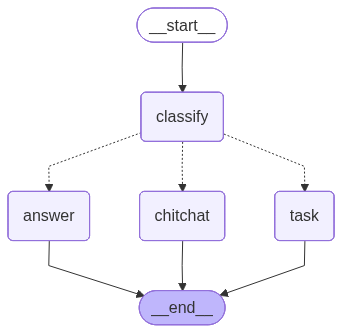

In [9]:
from IPython.display import Image, display;

display(Image(graph.get_graph().draw_mermaid_png()));

In [16]:
user_text = "What is the capital of Sweden?";

result = graph.invoke(
    {
        "messages": [HumanMessage(user_text)],
        "category": "",
        "response": ""
    }
);

print(f"\n❓ {user_text}");

print(f"📂 Category: {result["category"]}");

print(f"💬 Response: {result["response"]}...");

print("=" * 30);

[classify] → question

❓ What is the capital of Sweden?
📂 Category: question
💬 Response: The capital of Sweden is **Stockholm**....


In [14]:
user_text = "Write me a Python function to reverse a string";

result = graph.invoke(
    {
        "messages": [HumanMessage(user_text)],
        "category": "",
        "response": ""
    }
);

print(f"\n❓ {user_text}");

print(f"📂 Category: {result["category"]}");

print(f"💬 Response: {result["response"]}...");

print("=" * 30);

[classify] → task

❓ Write me a Python function to reverse a string
📂 Category: task
💬 Response: Here’s a concise, reusable Python function that reverses a string:

```python
def reverse_string(s: str) -> str:
    """
    Return a new string that is the reverse of the input.

    Parameters
    ----------
    s : str
        The string to be reversed.

    Returns
    -------
    str
        The reversed string.

    Examples
    --------
    >>> reverse_string("hello")
    'olleh'
    >>> reverse_string("")
    ''
    """
    # Pythonic way using slicing
    return s[::-1]
```

**How it works**

- `s[::-1]` is a slice that steps through the original string `s` backward:
  - The first `:` means “take the whole string”.
  - The second `:` introduces the step value.
  - `-1` tells Python to move from the end toward the start, producing the reversed order.

**Usage**

```python
if __name__ == "__main__":
    test = "OpenAI"
    print(f"Original: {test}")
    print(f"Reversed: {reverse_str

In [15]:
user_text = "Hey! How is your going";

result = graph.invoke(
    {
        "messages": [HumanMessage(user_text)],
        "category": "",
        "response": ""
    }
);

print(f"\n❓ {user_text}");

print(f"📂 Category: {result["category"]}");

print(f"💬 Response: {result["response"]}...");

print("=" * 30);

[classify] → chitchat

❓ Hey! How is your going
📂 Category: chitchat
💬 Response: Hey! I'm doing great—thanks for asking. How's your day going?...
